# Introduction

This notebook is for understanding how an LLM (chat model) can be used to route to a tool call if needed

# Import

In [18]:
import tomllib
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_openai import ChatOpenAI
from IPython.display import Image

# LLM with a Tool

In [3]:
# Loading secrets to get API key

with open("../secrets.toml", "rb") as f:
    secrets = tomllib.load(f)

In [5]:
# Creating the function to be used as a tool
def add_numbers(a: int, b: int) -> int:
    """Adds two numbers.

    Args:
        a (int): number 1
        b (int): number 2

    Returns:
        int: the sum of a and b
    """
    return a + b

llm = ChatOpenAI(model="gpt-4o", api_key=secrets["api_keys"]["openai"])
llm_with_tools = llm.bind_tools([add_numbers])

In [23]:
def llm_with_tools_node(state: MessagesState):
    return {"messages": llm_with_tools.invoke(state["messages"])}

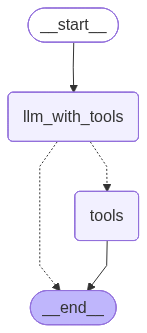

In [24]:
# Build graph

builder = StateGraph(MessagesState)
builder.add_node("llm_with_tools", llm_with_tools_node)
builder.add_node("tools", ToolNode([add_numbers]))
builder.add_edge(START, "llm_with_tools")
builder.add_conditional_edges("llm_with_tools", tools_condition)
builder.add_edge("tools", END)
graph = builder.compile()

# graph image
Image(graph.get_graph().draw_mermaid_png())

Note: The "ToolNode" here is creating a node that is doing the following:
1. Takes in the arguments to the function and the function itself as inputs
2. The ToolNode then executes the function
3. Appends the result of the tool call to the messages

# Invoking the Graph

## Invoke with Tool Call

In [25]:
res = graph.invoke({"messages": HumanMessage(content="What is 2 + 3?")})
for m in res["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 + 3?
================================== Ai Message ==================================
Tool Calls:
  add_numbers (call_oARn0hOnc1kw2Jt5se7wS4Ax)
 Call ID: call_oARn0hOnc1kw2Jt5se7wS4Ax
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: add_numbers

5


In [27]:
res

{'messages': [HumanMessage(content='What is 2 + 3?', additional_kwargs={}, response_metadata={}, id='589f1f14-4c08-41c0-b4c8-f7d2c7c27bdc'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 62, 'total_tokens': 80, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_73c9a1c5a5', 'id': 'chatcmpl-DJFhcDdimkD31bofSAv3FFEl83bco', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cebb3-eeda-71f1-8fc6-e88c7e49e868-0', tool_calls=[{'name': 'add_numbers', 'args': {'a': 2, 'b': 3}, 'id': 'call_oARn0hOnc1kw2Jt5se7wS4Ax', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 62, 'output_tokens': 18, 'total_

## Invoke without Tool Call

In [26]:
res2 = graph.invoke({"messages": HumanMessage(content="Why is the sky blue?")})
for m in res2["messages"]:
    m.pretty_print()

================================ Human Message =================================

Why is the sky blue?
================================== Ai Message ==================================

The sky appears blue due to a phenomenon called Rayleigh scattering. This occurs when sunlight interacts with the Earth's atmosphere. Sunlight, or white light, is composed of different colors, each with its own wavelength. Blue light has a shorter wavelength compared to other colors like red or yellow.

As sunlight passes through the atmosphere, the shorter wavelengths of light (blue and violet) are scattered in all directions by the gases and particles in the air. Although violet light is scattered even more than blue, our eyes are more sensitive to blue light and there is also more blue light in the sunlight reaching the Earth. Hence, we perceive the sky as blue.


**Next Step: Try to manually create a node that can execute function call and append to the state (try to create what is happening internally in ToolNode)**